In [26]:
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import animation
from matplotlib.animation import FuncAnimation

In [27]:
def updatePosition(pos, index, op):
    p = list(pos)
    p[index] += 1 if op else -1
    return tuple(p)


def setSpace(s):
    space_ = {}
    for w in range(s):
        for h in range(s):
            val = random.randint(1, 16)
            space_[(w, h)] = 'pizza' if val == 4 else 0

    w = random.randint(0, (len(space_) - 1) // s)
    h = random.randint(0, (len(space_) - 1) // s)
    pos = (w, h)
    space_[w, h] = 'agent'
    return space_, pos, s


def randomWalk(steps, space_, pos, s):
    health = 50
    pts = 0
    pos_list = [pos]
    for i in range(steps):
        direction = random.randint(1, 4)
        try:
            if space_[pos] == 'pizza':
                pts += 1
                if health < 50:
                    health += 1
            if direction == 1:
                space_[pos] = 1
                pos = updatePosition(pos, 1, True)
            elif direction == 2:
                space_[pos] = 1
                pos = updatePosition(pos, 1, False)
            elif direction == 3:
                space_[pos] = 1
                pos = updatePosition(pos, 0, True)
            else:
                space_[pos] = 1
                pos = updatePosition(pos, 0, False)
        except:
            print(f'You hit the wall! Ramaining HP is: {health}')
            health -= 1
            if health <= 0:
                print('Game Over!')
                return space_, pos_list, pts
            else:
                if pos[0] == -1:
                    pos = updatePosition(pos, 0, True)
                elif pos[0] == s:
                    pos = updatePosition(pos, 0, False)
                elif pos[1] == -1:
                    pos = updatePosition(pos, 1, True)
                elif pos[1] == s:
                    pos = updatePosition(pos, 1, False)
        pos_list.append(pos)

    return space_, pos_list, pts


You hit the wall! Ramaining HP is: 50
You hit the wall! Ramaining HP is: 49
You hit the wall! Ramaining HP is: 48
You hit the wall! Ramaining HP is: 47
You hit the wall! Ramaining HP is: 46
You hit the wall! Ramaining HP is: 47
You hit the wall! Ramaining HP is: 47
You hit the wall! Ramaining HP is: 46
You hit the wall! Ramaining HP is: 45
You hit the wall! Ramaining HP is: 48
You hit the wall! Ramaining HP is: 48
You hit the wall! Ramaining HP is: 47
You hit the wall! Ramaining HP is: 46
You hit the wall! Ramaining HP is: 45
You hit the wall! Ramaining HP is: 44
You hit the wall! Ramaining HP is: 43
You hit the wall! Ramaining HP is: 42
You hit the wall! Ramaining HP is: 41
You hit the wall! Ramaining HP is: 40
You hit the wall! Ramaining HP is: 39
You hit the wall! Ramaining HP is: 38
You hit the wall! Ramaining HP is: 37
You hit the wall! Ramaining HP is: 36
You hit the wall! Ramaining HP is: 35
You hit the wall! Ramaining HP is: 45
You hit the wall! Ramaining HP is: 44
You hit the 

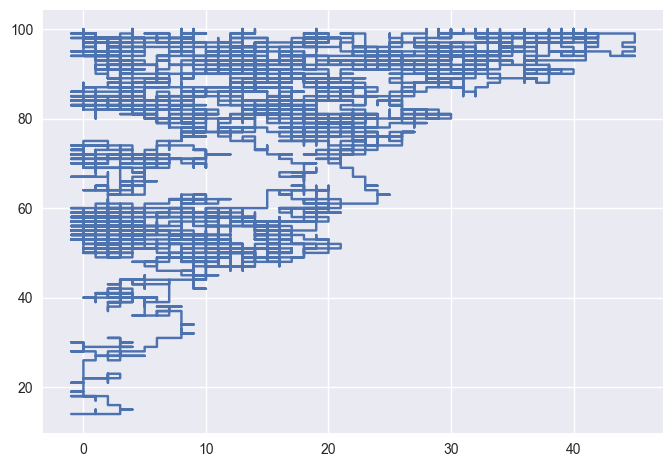

In [28]:
space, position, size = setSpace(100)
space, positions, points = randomWalk(10000, space, position, size)

x = [i[0] for i in positions]
y = [i[1] for i in positions]

plt.style.use('seaborn-v0_8')
plt.plot(x, y)
plt.show()

In [37]:
pos_array = np.array(positions)
pos_array

array([[21, 89],
       [20, 89],
       [20, 88],
       ...,
       [ 1, 14],
       [ 0, 14],
       [-1, 14]], shape=(6810, 2))

In [40]:
visited_pos = {positions[0]}

cropped_arr = [positions[0]]
for pos_idx in range(1, len(positions) - 1):
    pos = positions[pos_idx]
    prev_pos = positions[pos_idx - 1]
    if pos not in visited_pos:
        if cropped_arr[-1] != prev_pos:
            cropped_arr.append(prev_pos)
        cropped_arr.append(pos)
        visited_pos.add(pos)

cropped_arr = np.array(cropped_arr)
cropped_arr

array([[21, 89],
       [20, 89],
       [20, 88],
       ...,
       [ 1, 15],
       [ 1, 14],
       [ 0, 14]], shape=(2035, 2))

Animation size has reached 20995854 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.


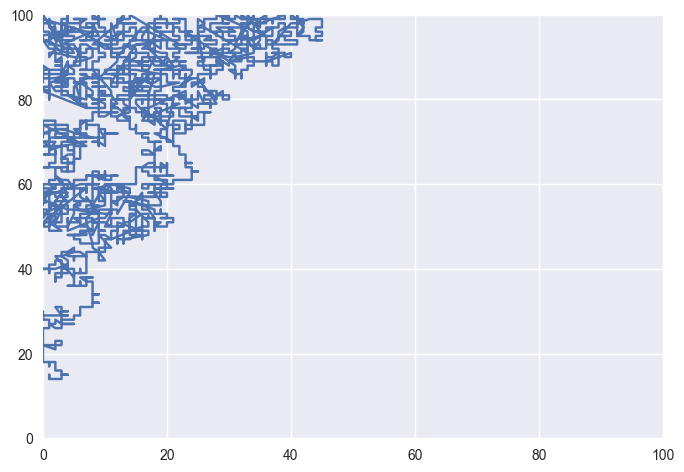

In [39]:
def update_frame(frame):
    line_plot.set_xdata([cropped_arr[:frame, 0]])
    line_plot.set_ydata(cropped_arr[:frame, 1])
    return line_plot

fig, ax = plt.subplots()
line_plot = ax.plot(cropped_arr[0, 0], cropped_arr[0, 1])[0]
ax.set(xlim=(0, size), ylim=(0, size))

ani = FuncAnimation(fig=fig, func=update_frame, frames=len(cropped_arr), interval=100)

with open('anim.html', 'w') as f:
    f.write(ani.to_jshtml())

# Q2

In [ ]:
import operator
import networkx as nx

G = nx.Graph()
G.add_nodes_from(["John", "Mary", "Jill", "Todd",
                  "iPhone5", "Kindle Fire", "Fitbit Flex Wireless", "Harry Potter", "Hobbit"])
G.add_edges_from([
    ("John", "iPhone5"),
    ("John", "Kindle Fire"),
    ("Mary", "iPhone5"),
    ("Mary", "Kindle Fire"),
    ("Mary", "Fitbit Flex Wireless"),
    ("Jill", "iPhone5"),
    ("Jill", "Kindle Fire"),
    ("Jill", "Fitbit Flex Wireless"),
    ("Todd", "Fitbit Flex Wireless"),
    ("Todd", "Harry Potter"),
    ("Todd", "Hobbit"),
])

In [ ]:
pr = nx.pagerank(G)
pr = sorted(pr.items(), key=operator.itemgetter(1), reverse=True)

print('PageRank')
pd.DataFrame(pr, columns=['item', 'score'])

In [ ]:
ppr = nx.pagerank(G, personalization={"John": 1})
ppr = sorted(ppr.items(), key=operator.itemgetter(1), reverse=True)

print('Personalised PageRank')
pd.DataFrame(ppr, columns=['item', 'score'])